<a href="https://colab.research.google.com/github/dayanamichellgomezmartinez-ux/Notebooks_Agro_2026_1/blob/main/Trabajo_Aplicado_Funciones_Estructuras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TRABAJO APLICADO: FUNCIONES Y ESTRUCTURAS DE DATOS EN PYTHON
**Asignatura:** Fundamentos de Programación  

**Programa:** Ingeniería Agroindustrial

**Universidad:** Universidad de Sucre  

**Estudiantes:** Dayana Gómez, Giovanni Berrios, Victor Teheran, Junior Ordogoistia, Adrian Carmona y Jonas Pineda   

**Fecha:** 07/06/2026

## Introducción
El presente trabajo aplicado integra conceptos de programación en Python, tales como funciones, estructuras de control y colecciones de datos, para solucionar problemas del entorno agroindustrial y ambiental. Específicamente, se abordan el diseño hidráulico de canales de riego, la optimización nutricional de mezclas y el análisis financiero del proyecto.

In [1]:
# =====================================================================
# CELDA 1: IMPORTACIÓN DE LIBRERÍAS
# =====================================================================
import math
import matplotlib.pyplot as plt

print("Librerías cargadas correctamente. ¡Listo para iniciar los módulos!")

Librerías cargadas correctamente. ¡Listo para iniciar los módulos!


## Módulo 1: Ingeniería de Riego e Hidráulica
En esta sección se automatiza el cálculo de un canal trapezoidal utilizando la ecuación de Manning para determinar el caudal de diseño ($Q$) y verificar la velocidad del flujo, asegurando que satisfaga las necesidades hídricas del cultivo basadas en la evapotranspiración de referencia ($ETo$).

In [2]:
# =====================================================================
# CELDA 2: MÓDULO DE HIDRÁULICA Y RIEGO
# =====================================================================

def calcular_canal_trapezoidal(b, z, y, s, n):
    """
    Calcula los parámetros hidráulicos de un canal trapezoidal utilizando la ecuación de Manning.
    b = base del canal (m)
    z = talud (relación horizontal/vertical)
    y = tirante o profundidad del agua (m)
    s = pendiente del canal (m/m)
    n = coeficiente de rugosidad de Manning
    """
    # 1. Cálculo del Área Transversal (A)
    area = (b + z * y) * y

    # 2. Cálculo del Perímetro Mojado (P)
    perimetro = b + 2 * y * math.sqrt(1 + z**2)

    # 3. Cálculo del Radio Hidráulico (R)
    if perimetro > 0:
        radio_hidraulico = area / perimetro
    else:
        radio_hidraulico = 0

    # 4. Cálculo de la Velocidad del flujo (v) usando Manning
    # Fórmula: v = (1/n) * (R^(2/3)) * (s^(1/2))
    velocidad = (1 / n) * (radio_hidraulico ** (2/3)) * (math.sqrt(s))

    # 5. Cálculo del Caudal (Q)
    # Fórmula: Q = v * A
    caudal = velocidad * area

    # Retornamos los resultados organizados en un diccionario de datos
    return {
        "Area (m2)": round(area, 4),
        "Perimetro (m)": round(perimetro, 4),
        "Radio Hidraulico (m)": round(radio_hidraulico, 4),
        "Velocidad (m/s)": round(velocidad, 4),
        "Caudal (m3/s)": round(caudal, 4)
    }

# Prueba rápida del módulo para verificar que funcione
print("Módulo de hidráulica definido con éxito.")

Módulo de hidráulica definido con éxito.


## Módulo 2: Formulación de Mezclas Nutricionales
Este módulo aplica un balance lineal (inspirado en métodos como el Cuadrado de Pearson) para optimizar la inclusión porcentual de dos materias primas (Maíz y Soya) con el fin de alcanzar una meta de Proteína Bruta (PB) específica en un producto agroindustrial.

In [3]:
# =====================================================================
# CELDA 3: MÓDULO DE FORMULACIÓN DE MEZCLAS
# =====================================================================

def optimizar_mezcla_nutricional(insumo_A, insumo_B, meta_nutriente):
    """
    Calcula los porcentajes requeridos de dos insumos para cumplir una meta nutricional.
    insumo_A: diccionario con {'nombre': str, 'aporte': float}
    insumo_B: diccionario con {'nombre': str, 'aporte': float}
    meta_nutriente: porcentaje objetivo del nutriente en la mezcla total.
    """
    ap_A = insumo_A['aporte']
    ap_B = insumo_B['aporte']

    # Validación matemática: la meta debe estar entre los aportes de ambos insumos
    if not (min(ap_A, ap_B) <= meta_nutriente <= max(ap_A, ap_B)):
        return "Error: La meta no es alcanzable con los aportes de los insumos seleccionados."

    # Cálculo de proporciones empleando diferencias cruzadas (Lógica de mezcla lineal)
    dif_A = abs(ap_B - meta_nutriente)
    dif_B = abs(ap_A - meta_nutriente)
    suma_total_diferencias = dif_A + dif_B

    # Convertir a porcentajes (0% a 100%)
    porcentaje_A = (dif_A / suma_total_diferencias) * 100
    porcentaje_B = (dif_B / suma_total_diferencias) * 100

    return {
        insumo_A['nombre']: round(porcentaje_A, 2),
        insumo_B['nombre']: round(porcentaje_B, 2)
    }

# Prueba rápida del módulo
print("Módulo de formulación de mezclas definido con éxito.")

Módulo de formulación de mezclas definido con éxito.


## Módulo 3: Análisis Financiero y Reporte Automatizado
Función encargada de unificar los datos técnicos obtenidos previamente, evaluar los costos de infraestructura y operación del lote de producción, y generar un informe final formateado para la toma de decisiones.

In [4]:
# =====================================================================
# CELDA 4: MÓDULO DE COSTOS Y REPORTES
# =====================================================================

def generar_reporte_economico(datos_hidraulicos, datos_mezcla, precio_metro_canal, precio_ton_mezcla, volumen_obra):
    """
    Genera un informe financiero y técnico integrado basado en los resultados previos.
    """
    # Cálculo de costos financieros
    costo_infraestructura = volumen_obra * precio_metro_canal
    costo_operacion_mezcla = 10 * precio_ton_mezcla # Asumiendo un lote estándar de 10 Toneladas
    costo_total_proyecto = costo_infraestructura + costo_operacion_mezcla

    # Construcción de la cadena del reporte en texto legible y elegante
    reporte = "==================================================\n"
    reporte += "        INFORME TÉCNICO-ECONÓMICO DEL PROYECTO     \n"
    reporte += "==================================================\n\n"

    reporte += "1. COMPONENTE HIDRÁULICO Y DE RIEGO:\n"
    for clave, valor in datos_hidraulicos.items():
        reporte += f"   - {clave}: {valor}\n"
    reporte += "\n"

    reporte += "2. COMPONENTE DE FORMULACIÓN DE MEZCLAS:\n"
    for ingrediente, pct in datos_mezcla.items():
        reporte += f"   - Porcentaje de {ingrediente}: {pct}%\n"
    reporte += "\n"

    reporte += "3. ANÁLISIS FINANCIERO ESTIMADO:\n"
    reporte += f"   - Costo Estimado de Infraestructura: ${costo_infraestructura:,.2f} COP\n"
    reporte += f"   - Costo Estimado de Operación/Insumos: ${costo_operacion_mezcla:,.2f} COP\n"
    reporte += f"   - INVERSIÓN TOTAL DEL PROYECTO: ${costo_total_proyecto:,.2f} COP\n"
    reporte += "==================================================\n"

    return reporte

print("Módulo de costos y reportes definido con éxito.")

Módulo de costos y reportes definido con éxito.


## Módulo 4: Visualización de Datos y Resultados
Ejecución del sistema integrado y generación de gráficos interactivos que muestran el comportamiento del caudal respecto al tirante de agua y la distribución porcentual de los insumos de la mezcla.

In [7]:
import math
import matplotlib.pyplot as plt

# =====================================================================
# CELDA 5: MÓDULO DE VISUALIZACIÓN GRÁFICA
# =====================================================================

def generar_graficos_proyecto(datos_mezcla, b, z, s, n):
    """
    Crea las gráficas del comportamiento hidráulico y del balance agroindustrial.
    """
    # ---- GRÁFICA 1: Variación del Caudal según el Tirante de Agua ----
    tirantes_simulados = [i * 0.1 for i in range(1, 11)] # Genera valores desde 0.1m hasta 1.0m
    caudales_calculados = []

    for y_sim in tirantes_simulados:
        # Reutilizamos la lógica matemática de la Celda 2
        area_sim = (b + z * y_sim) * y_sim
        perimetro_sim = b + 2 * y_sim * math.sqrt(1 + z**2)
        radio_sim = area_sim / perimetro_sim if perimetro_sim > 0 else 0
        vel_sim = (1 / n) * (radio_sim ** (2/3)) * (math.sqrt(s))
        caudales_calculados.append(vel_sim * area_sim)

    plt.figure(figsize=(12, 5))

    # Primer subgráfico (Línea para Hidráulica)
    plt.subplot(1, 2, 1)
    plt.plot(tirantes_simulados, caudales_calculados, color='teal', marker='o', linestyle='--')
    plt.title("Comportamiento del Caudal según el Tirante")
    plt.xlabel("Tirante de Agua (m)")
    plt.ylabel("Caudal Estimado (m3/s)")
    plt.grid(True)

    # ---- GRÁFICA 2: Distribución de la Mezcla Formulada ----
    plt.subplot(1, 2, 2)
    ingredientes = list(datos_mezcla.keys())
    porcentajes = list(datos_mezcla.values())

    plt.bar(ingredientes, porcentajes, color=['coral', 'olivedrab'])
    plt.title("Distribución Porcentual de la Mezcla")
    plt.ylabel("Porcentaje (%)")
    plt.ylim(0, 100)

    # Añadir los valores numéricos encima de las barras
    for i, v in enumerate(porcentajes):
        plt.text(i, v + 2, f"{v}%", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

print("Módulo de visualización gráfica definido con éxito.")

Módulo de visualización gráfica definido con éxito.


        INFORME TÉCNICO-ECONÓMICO DEL PROYECTO     

1. COMPONENTE HIDRÁULICO Y DE RIEGO:
   - Area (m2): 1.08
   - Perimetro (m): 2.8971
   - Radio Hidraulico (m): 0.3728
   - Velocidad (m/s): 1.5443
   - Caudal (m3/s): 1.6679

2. COMPONENTE DE FORMULACIÓN DE MEZCLAS:
   - Porcentaje de Maíz Grano: 73.24%
   - Porcentaje de Harina de Soya: 26.76%

3. ANÁLISIS FINANCIERO ESTIMADO:
   - Costo Estimado de Infraestructura: $7,500,000.00 COP
   - Costo Estimado de Operación/Insumos: $8,500,000.00 COP
   - INVERSIÓN TOTAL DEL PROYECTO: $16,000,000.00 COP



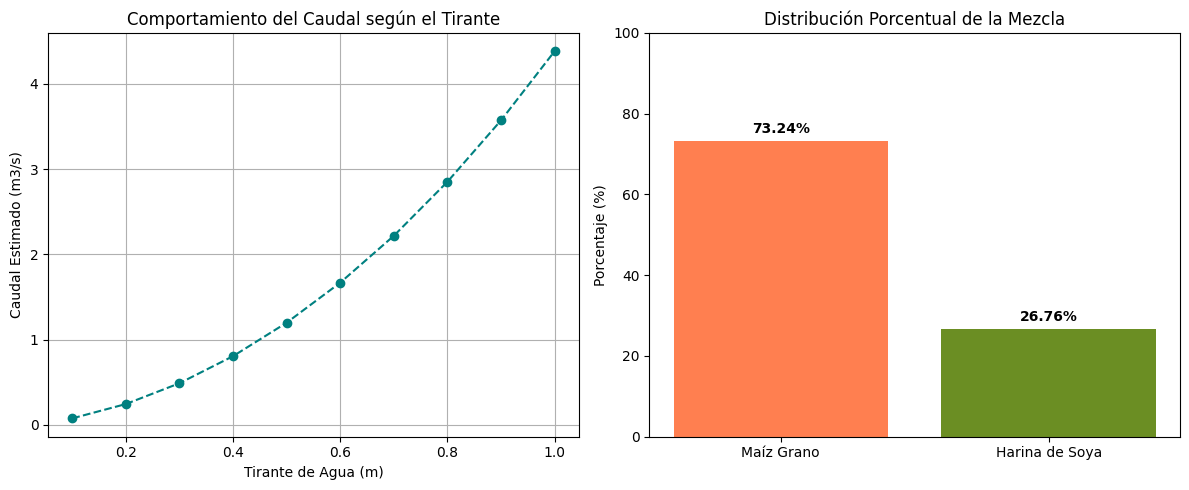

In [8]:
# =====================================================================
# CELDA 6: EJECUCIÓN GENERAL DE NUESTRO PROYECTO
# =====================================================================

# 1. Definición de parámetros para el Canal de Riego
base_canal = 1.2    # metros
talud_canal = 1.0   # z = 1 (canal trapezoidal común)
tirante_agua = 0.6  # metros de profundidad del flujo
pendiente = 0.002   # s (2 metros por cada 1000 metros)
rugosidad = 0.015   # n (concreto liso o tierra compactada limpia)

# Ejecutar cálculo hidráulico
resultados_hidraulica = calcular_canal_trapezoidal(base_canal, talud_canal, tirante_agua, pendiente, rugosidad)

# 2. Definición de parámetros para la Mezcla Agroindustrial
# Supongamos un balance de Proteína Bruta (PB) para alimentación animal
maiz_grano = {'nombre': 'Maíz Grano', 'aporte': 8.5}     # Aporta 8.5% de proteína
harina_soya = {'nombre': 'Harina de Soya', 'aporte': 44.0} # Aporta 44% de proteína
proteina_objetivo = 18.0                                   # Queremos una mezcla final al 18%

# Ejecutar optimización de la mezcla
resultados_mezcla = optimizar_mezcla_nutricional(maiz_grano, harina_soya, proteina_objetivo)

# 3. Datos financieros base
precio_infraestructura_metro = 150000  # Costo por metro de canal construido
precio_tonelada_insumos = 850000      # Costo promedio por tonelada de mezcla procesada
longitud_obra = 50                     # Construiremos 50 metros de canal

# 4. Generación e impresión del Reporte Final Integrado
informe_final = generar_reporte_economico(
    resultados_hidraulica,
    resultados_mezcla,
    precio_infraestructura_metro,
    precio_tonelada_insumos,
    longitud_obra
)

print(informe_final)

# 5. Desplegar los gráficos explicativos del proyecto
generar_graficos_proyecto(resultados_mezcla, base_canal, talud_canal, pendiente, rugosidad)